In [1]:
%pip install -q "gymnasium[atari]==1.2.0" "ale-py==0.11.2"

import random
import collections
import gc
import time
import json
import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym
import ale_py
from gymnasium.wrappers import AtariPreprocessing, FrameStackObservation
import torch
import torch.nn as nn
import torch.optim as optim


SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

gym.register_envs(ale_py)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Dispositivo:", device, flush=True)


class FireResetEnv(gym.Wrapper):
    """Preme FIRE all'avvio dell'episodio."""

    def reset(self, **kwargs):
        obs, info = self.env.reset(**kwargs)
        obs, _, term, trunc, info = self.env.step(1)
        if term or trunc:
            obs, info = self.env.reset(**kwargs)
        return obs, info


class PongThreeActions(gym.ActionWrapper):
    """Espone soltanto NOOP (0), UP/RIGHT (2), DOWN/LEFT (3)."""

    def __init__(self, env):
        super().__init__(env)
        self.action_mapping = [0, 2, 3]
        self.action_space = gym.spaces.Discrete(3)

    def action(self, action):
        return self.action_mapping[int(action)]


def set_all_seeds(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

Note: you may need to restart the kernel to use updated packages.
Dispositivo: cuda


In [2]:
class PongAlignmentPotential:
    """Potenziale geometrico basato sull'allineamento pallina-racchetta."""

    def __init__(
        self,
        scale=0.10,
        play_y=(8, 80),
        ball_x=(10, 70),
        player_x=(70, 82),
        contrast_threshold=35,
        motion_threshold=10,
        max_ball_pixels=40,
    ):
        if scale < 0.0:
            raise ValueError("scale deve essere non negativo")
        self.scale = float(scale)
        self.play_y = tuple(play_y)
        self.ball_x = tuple(ball_x)
        self.player_x = tuple(player_x)
        self.contrast_threshold = float(contrast_threshold)
        self.motion_threshold = float(motion_threshold)
        self.max_ball_pixels = int(max_ball_pixels)

    @staticmethod
    def _last_two_frames(observation):
        frames = np.asarray(observation)
        if frames.ndim == 2:
            return frames, frames
        if frames.ndim != 3 or frames.shape[0] < 2:
            raise ValueError(
                "Il potenziale richiede un frame 84x84 o uno stack (N, 84, 84)"
            )
        return frames[-2], frames[-1]

    def estimate(self, observation):
        previous, current = self._last_two_frames(observation)
        previous = previous.astype(np.int16, copy=False)
        current = current.astype(np.int16, copy=False)
        height, width = current.shape

        y0, y1 = self.play_y
        bx0, bx1 = self.ball_x
        px0, px1 = self.player_x

        if not (0 <= y0 < y1 <= height and 0 <= bx0 < bx1 <= width):
            raise ValueError("Regione della pallina non compatibile con il frame")
        if not (0 <= px0 < px1 <= width):
            raise ValueError("Regione della racchetta non compatibile con il frame")


        background = float(np.median(current[y0:y1, bx0:bx1]))


        paddle_roi = current[y0:y1, px0:px1]
        paddle_mask = np.abs(paddle_roi - background) >= self.contrast_threshold
        paddle_y_local, _ = np.nonzero(paddle_mask)
        paddle_y = (
            float(np.median(paddle_y_local + y0))
            if paddle_y_local.size >= 2
            else None
        )


        ball_current = current[y0:y1, bx0:bx1]
        ball_previous = previous[y0:y1, bx0:bx1]
        object_mask = (
            np.abs(ball_current - background) >= self.contrast_threshold
        )
        moving_mask = (
            np.abs(ball_current - ball_previous) >= self.motion_threshold
        )
        ball_mask = object_mask & moving_mask
        ball_y_local, ball_x_local = np.nonzero(ball_mask)

        valid_ball = 1 <= ball_y_local.size <= self.max_ball_pixels
        ball_y = (
            float(np.median(ball_y_local + y0)) if valid_ball else None
        )
        ball_x = (
            float(np.median(ball_x_local + bx0)) if valid_ball else None
        )

        return {
            "ball_y": ball_y,
            "ball_x": ball_x,
            "paddle_y": paddle_y,
            "background": background,
            "detected": ball_y is not None and paddle_y is not None,
        }

    def __call__(self, observation):
        objects = self.estimate(observation)
        if not objects["detected"]:
            return 0.0

        height = np.asarray(observation).shape[-2]
        vertical_error = abs(objects["ball_y"] - objects["paddle_y"])
        alignment = 1.0 - vertical_error / max(1, height - 1)
        return self.scale * float(np.clip(alignment, 0.0, 1.0))


class PotentialBasedRewardShaping(gym.Wrapper):
    """Applica F(s,s') = gamma * Phi(s') - Phi(s)."""

    def __init__(self, env, potential_fn, gamma):
        super().__init__(env)
        if not 0.0 <= gamma <= 1.0:
            raise ValueError("gamma deve appartenere a [0, 1]")
        self.potential_fn = potential_fn
        self.gamma = float(gamma)
        self.current_potential = 0.0

    def reset(self, **kwargs):
        observation, info = self.env.reset(**kwargs)
        self.current_potential = float(self.potential_fn(observation))
        info = dict(info)
        info["potential"] = self.current_potential
        return observation, info

    def step(self, action):
        observation, raw_reward, terminated, truncated, info = self.env.step(action)
        raw_reward = float(raw_reward)



        next_potential = (
            0.0
            if terminated
            else float(self.potential_fn(observation))
        )
        shaping_reward = (
            self.gamma * next_potential - self.current_potential
        )
        shaped_reward = raw_reward + shaping_reward

        info = dict(info)
        info["raw_reward"] = raw_reward
        info["shaping_reward"] = shaping_reward
        info["potential_s"] = self.current_potential
        info["potential_next"] = next_potential

        self.current_potential = next_potential
        return observation, shaped_reward, terminated, truncated, info

In [3]:
class DQN(nn.Module):
    def __init__(self, n_actions):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(4, 32, 8, stride=4),
            nn.ReLU(),
            nn.Conv2d(32, 64, 4, stride=2),
            nn.ReLU(),
            nn.Conv2d(64, 64, 3, stride=1),
            nn.ReLU(),
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 512),
            nn.ReLU(),
            nn.Linear(512, n_actions),
        )

    def forward(self, x):
        return self.net(x / 255.0)


class ReplayBuffer:
    def __init__(self, capacity=100000):
        self.buffer = collections.deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, terminated):
        self.buffer.append(
            (
                np.array(state, dtype=np.uint8),
                action,
                reward,
                np.array(next_state, dtype=np.uint8),
                terminated,
            )
        )

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        state, action, reward, next_state, terminated = zip(*batch)
        return (
            torch.tensor(np.array(state), dtype=torch.uint8, device=device).float(),
            torch.tensor(action, dtype=torch.int64, device=device),
            torch.tensor(reward, dtype=torch.float32, device=device),
            torch.tensor(np.array(next_state), dtype=torch.uint8, device=device).float(),
            torch.tensor(terminated, dtype=torch.float32, device=device),
        )

    def __len__(self):
        return len(self.buffer)


def evaluate(eval_env, model=None, episodes=20, base_seed=1000):
    """Valuta sempre sul reward Atari originale, senza PBRS."""
    scores = []
    for episode in range(episodes):
        state, _ = eval_env.reset(seed=base_seed + episode)
        if model is None:
            eval_env.action_space.seed(base_seed + episode)

        done = False
        total_reward = 0.0
        while not done:
            if model is None:
                action = eval_env.action_space.sample()
            else:
                state_t = torch.tensor(
                    np.array(state), dtype=torch.uint8, device=device
                ).float().unsqueeze(0)
                with torch.no_grad():
                    action = model(state_t).argmax(dim=1).item()

            state, reward, term, trunc, _ = eval_env.step(action)
            done = term or trunc
            total_reward += reward

        scores.append(total_reward)

    return float(np.mean(scores)), float(np.std(scores))

In [4]:

BUFFER_CAPACITY = 100000
TOTAL_STEPS = 1800000
LEARNING_STARTS = 20000
TRAIN_FREQ = 4
EPS_START = 1.0
EPS_END = 0.01
DECAY_STEPS = 800000
GAMMA = 0.99
BATCH_SIZE = 64
LR = 1e-4
TARGET_UPDATE = 2000
CHECKPOINTS = [600000, 900000, 1200000, 1500000, 1800000]
EVAL_EPISODES = 20


SMALL_POTENTIAL_SCALE = 0.02
MODERATE_POTENTIAL_SCALE = 0.10
AGGRESSIVE_POTENTIAL_SCALE = 0.50
POTENTIAL_KWARGS = {
    "play_y": (8, 80),
    "ball_x": (10, 70),
    "player_x": (70, 82),
    "contrast_threshold": 35,
    "motion_threshold": 10,
    "max_ball_pixels": 40,
}

assert TOTAL_STEPS in CHECKPOINTS
assert 0 < SMALL_POTENTIAL_SCALE < MODERATE_POTENTIAL_SCALE < AGGRESSIVE_POTENTIAL_SCALE


def make_env(use_pbrs=False, potential_scale=MODERATE_POTENTIAL_SCALE):
    env = gym.make("ALE/Pong-v5", frameskip=1)
    env = AtariPreprocessing(
        env,
        noop_max=30,
        frame_skip=4,
        screen_size=84,
        terminal_on_life_loss=False,
        grayscale_obs=True,
        scale_obs=False,
    )
    env = FireResetEnv(env)
    env = PongThreeActions(env)
    env = FrameStackObservation(env, stack_size=4)


    if use_pbrs:
        env = PotentialBasedRewardShaping(
            env,
            potential_fn=PongAlignmentPotential(scale=potential_scale, **POTENTIAL_KWARGS),
            gamma=GAMMA,
        )

    return env

A.L.E: Arcade Learning Environment (version 0.11.2+ecc1138)
[Powered by Stella]


Rilevamento completo in 302/500 passi (60.4%).


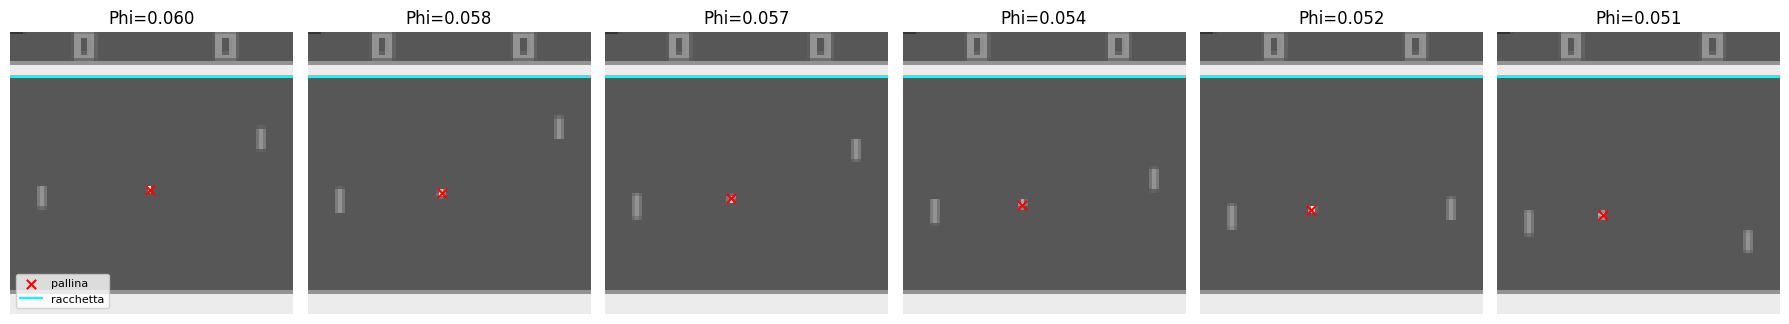

In [5]:
def inspect_potential_detector(n_samples=6, max_steps=500, seed=SEED):
    detector = PongAlignmentPotential(scale=MODERATE_POTENTIAL_SCALE, **POTENTIAL_KWARGS)
    diagnostic_env = make_env(use_pbrs=False)
    diagnostic_env.action_space.seed(seed)
    state, _ = diagnostic_env.reset(seed=seed)

    samples = []
    detected_steps = 0
    for _ in range(max_steps):
        action = diagnostic_env.action_space.sample()
        state, _, term, trunc, _ = diagnostic_env.step(action)
        objects = detector.estimate(state)
        detected_steps += int(objects["detected"])

        if objects["detected"] and len(samples) < n_samples:
            samples.append((np.asarray(state)[-1].copy(), objects, detector(state)))

        if term or trunc:
            state, _ = diagnostic_env.reset()

    diagnostic_env.close()
    print(
        f"Rilevamento completo in {detected_steps}/{max_steps} passi "
        f"({100 * detected_steps / max_steps:.1f}%)."
    )

    if not samples:
        print("Nessun campione valido: correggere regioni o soglie.")
        return

    fig, axes = plt.subplots(1, len(samples), figsize=(3 * len(samples), 4))
    axes = np.atleast_1d(axes)
    for axis, (frame, objects, potential) in zip(axes, samples):
        axis.imshow(frame, cmap="gray", vmin=0, vmax=255)
        axis.scatter(
            objects["ball_x"],
            objects["ball_y"],
            c="red",
            s=45,
            marker="x",
            label="pallina",
        )
        axis.axhline(
            objects["paddle_y"],
            color="cyan",
            linewidth=1.5,
            label="racchetta",
        )
        axis.set_title(f"Phi={potential:.3f}")
        axis.axis("off")

    axes[0].legend(loc="lower left", fontsize=8)
    plt.tight_layout()
    plt.show()


inspect_potential_detector()

In [6]:
def train_pbrs_experiment(label, potential_scale, seed=SEED):
    """Addestra da zero una scala PBRS e restituisce checkpoint e history."""
    set_all_seeds(seed)
    scale_tag = format(potential_scale, ".12g").replace(".", "p")
    print(f"\n=== {label}: scala={potential_scale:g}, seed={seed} ===", flush=True)
    env = make_env(use_pbrs=True, potential_scale=potential_scale)
    eval_env = make_env(use_pbrs=False)
    env.action_space.seed(seed)
    eval_env.action_space.seed(seed + 1)

    n_actions = env.action_space.n
    policy_net = DQN(n_actions).to(device)
    target_net = DQN(n_actions).to(device)
    target_net.load_state_dict(policy_net.state_dict())
    target_net.eval()

    optimizer = optim.Adam(policy_net.parameters(), lr=LR)
    loss_fn = nn.SmoothL1Loss()
    buffer = ReplayBuffer(capacity=BUFFER_CAPACITY)

    state, reset_info = env.reset(seed=seed)
    initial_potential = float(reset_info["potential"])

    raw_ep_return = 0.0
    shaped_ep_return = 0.0
    shaping_ep_sum = 0.0
    discounted_shaping_sum = 0.0
    discount_power = 1.0
    potential_sum = initial_potential
    abs_shaping_sum = 0.0
    episode_steps = 0

    history = {
        "step": [],
        "raw_return": [],
        "shaped_return": [],
        "shaping_sum": [],
        "mean_potential": [],
        "mean_abs_shaping": [],
        "telescoping_error": [],
        "loss": [],
    }
    checkpoint_results = {}

    policy_net.train()
    start_time = time.time()

    for step in range(1, TOTAL_STEPS + 1):
        epsilon = max(
            EPS_END,
            EPS_START - (EPS_START - EPS_END) * (step / DECAY_STEPS),
        )

        if random.random() < epsilon:
            action = env.action_space.sample()
        else:
            state_t = torch.tensor(
                np.array(state), dtype=torch.uint8, device=device
            ).float().unsqueeze(0)
            with torch.no_grad():
                action = policy_net(state_t).argmax(dim=1).item()

        next_state, shaped_reward, term, trunc, info = env.step(action)
        raw_reward = info["raw_reward"]
        shaping_reward = info["shaping_reward"]
        next_potential = info["potential_next"]



        buffer.push(state, action, shaped_reward, next_state, term)
        state = next_state

        raw_ep_return += raw_reward
        shaped_ep_return += shaped_reward
        shaping_ep_sum += shaping_reward
        discounted_shaping_sum += discount_power * shaping_reward
        discount_power *= GAMMA
        potential_sum += next_potential
        abs_shaping_sum += abs(shaping_reward)
        episode_steps += 1

        if term or trunc:

            telescoping_target = (
                -initial_potential + discount_power * next_potential
            )
            telescoping_error = discounted_shaping_sum - telescoping_target

            history["step"].append(step)
            history["raw_return"].append(raw_ep_return)
            history["shaped_return"].append(shaped_ep_return)
            history["shaping_sum"].append(shaping_ep_sum)
            history["mean_potential"].append(
                potential_sum / max(1, episode_steps + 1)
            )
            history["mean_abs_shaping"].append(
                abs_shaping_sum / max(1, episode_steps)
            )
            history["telescoping_error"].append(telescoping_error)

            if len(history["raw_return"]) % 20 == 0:
                elapsed = (time.time() - start_time) / 60.0
                print(
                    f"{label} | Step {step:7d}/{TOTAL_STEPS} | "
                    f"Episodio {len(history['raw_return']):4d} | "
                    f"Raw20 {np.mean(history['raw_return'][-20:]):6.2f} | "
                    f"Shaped20 {np.mean(history['shaped_return'][-20:]):6.2f} | "
                    f"|F| medio20 {np.mean(history['mean_abs_shaping'][-20:]):.4f} | "
                    f"eps {epsilon:.3f} | {elapsed:.1f}m",
                    flush=True,
                )

            state, reset_info = env.reset()
            initial_potential = float(reset_info["potential"])
            raw_ep_return = 0.0
            shaped_ep_return = 0.0
            shaping_ep_sum = 0.0
            discounted_shaping_sum = 0.0
            discount_power = 1.0
            potential_sum = initial_potential
            abs_shaping_sum = 0.0
            episode_steps = 0

        if step > LEARNING_STARTS and step % TRAIN_FREQ == 0:
            b_s, b_a, b_r, b_ns, b_terminated = buffer.sample(BATCH_SIZE)

            with torch.no_grad():
                max_next_q = target_net(b_ns).max(dim=1).values
                target_q = b_r + (1.0 - b_terminated) * GAMMA * max_next_q

            current_q = policy_net(b_s).gather(1, b_a.unsqueeze(1)).squeeze(1)
            loss = loss_fn(current_q, target_q)

            optimizer.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(policy_net.parameters(), 1.0)
            optimizer.step()
            history["loss"].append(loss.item())

        if step % TARGET_UPDATE == 0:
            target_net.load_state_dict(policy_net.state_dict())

        if step % 100000 == 0:
            gc.collect()
            if torch.cuda.is_available():
                torch.cuda.empty_cache()

        if step in CHECKPOINTS:
            policy_net.eval()
            mean_score, std_score = evaluate(
                eval_env,
                model=policy_net,
                episodes=EVAL_EPISODES,
            )
            policy_net.train()
            checkpoint_results[step] = (mean_score, std_score)
            print(
                f"\n--- Checkpoint {step} passi ({label}, scala {potential_scale:g}, reward Atari): "
                f"{mean_score:.2f} +/- {std_score:.2f} ---\n",
                flush=True,
            )

            torch.save(
                {
                    "step": step,
                    "policy_state_dict": policy_net.state_dict(),
                    "target_state_dict": target_net.state_dict(),
                    "optimizer_state_dict": optimizer.state_dict(),
                    "gamma": GAMMA,
                    "potential_scale": potential_scale,
                    "seed": seed,
                    "label": label,
                    "potential_kwargs": dict(POTENTIAL_KWARGS, scale=potential_scale),
                },
                f"dqn_pong_pbrs_scale_{scale_tag}_seed_{seed}_{step}.pth",
            )

    env.close()
    eval_env.close()

    result = {
        "label": label,
        "potential_scale": potential_scale,
        "seed": seed,
        "gamma": GAMMA,
        "potential_kwargs": dict(POTENTIAL_KWARGS, scale=potential_scale),
        "checkpoints": checkpoint_results,
        "history": history,
    }
    with open(f"risultati_pbrs_scale_{scale_tag}_seed_{seed}.json", "w", encoding="utf-8") as f:
        json.dump(result, f, ensure_ascii=False, indent=2)
    del buffer, policy_net, target_net, optimizer
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    return result

In [7]:
small_run = train_pbrs_experiment(
    label="PBRS scala piccola",
    potential_scale=SMALL_POTENTIAL_SCALE,
)


=== PBRS scala piccola: scala=0.02, seed=42 ===
PBRS scala piccola | Step   19060/1800000 | Episodio   20 | Raw20 -20.75 | Shaped20 -20.81 | |F| medio20 0.0015 | eps 0.976 | 0.5m
PBRS scala piccola | Step   39284/1800000 | Episodio   40 | Raw20 -20.40 | Shaped20 -20.47 | |F| medio20 0.0016 | eps 0.951 | 1.5m
PBRS scala piccola | Step   59102/1800000 | Episodio   60 | Raw20 -20.45 | Shaped20 -20.52 | |F| medio20 0.0017 | eps 0.927 | 2.5m
PBRS scala piccola | Step   79228/1800000 | Episodio   80 | Raw20 -20.15 | Shaped20 -20.22 | |F| medio20 0.0017 | eps 0.902 | 3.5m
PBRS scala piccola | Step  100407/1800000 | Episodio  100 | Raw20 -20.40 | Shaped20 -20.48 | |F| medio20 0.0018 | eps 0.876 | 4.6m
PBRS scala piccola | Step  121418/1800000 | Episodio  120 | Raw20 -20.55 | Shaped20 -20.63 | |F| medio20 0.0017 | eps 0.850 | 5.6m
PBRS scala piccola | Step  143120/1800000 | Episodio  140 | Raw20 -20.30 | Shaped20 -20.38 | |F| medio20 0.0018 | eps 0.823 | 6.8m
PBRS scala piccola | Step  166516/

In [8]:
moderate_run = train_pbrs_experiment(
    label="PBRS scala moderata",
    potential_scale=MODERATE_POTENTIAL_SCALE,
)


=== PBRS scala moderata: scala=0.1, seed=42 ===
PBRS scala moderata | Step   19060/1800000 | Episodio   20 | Raw20 -20.75 | Shaped20 -21.06 | |F| medio20 0.0077 | eps 0.976 | 0.4m
PBRS scala moderata | Step   39049/1800000 | Episodio   40 | Raw20 -20.20 | Shaped20 -20.54 | |F| medio20 0.0087 | eps 0.952 | 1.4m
PBRS scala moderata | Step   58765/1800000 | Episodio   60 | Raw20 -20.35 | Shaped20 -20.68 | |F| medio20 0.0085 | eps 0.927 | 2.3m
PBRS scala moderata | Step   78980/1800000 | Episodio   80 | Raw20 -20.55 | Shaped20 -20.90 | |F| medio20 0.0079 | eps 0.902 | 3.3m
PBRS scala moderata | Step   98735/1800000 | Episodio  100 | Raw20 -20.45 | Shaped20 -20.80 | |F| medio20 0.0098 | eps 0.878 | 4.3m
PBRS scala moderata | Step  119232/1800000 | Episodio  120 | Raw20 -20.60 | Shaped20 -20.97 | |F| medio20 0.0093 | eps 0.852 | 5.4m
PBRS scala moderata | Step  141279/1800000 | Episodio  140 | Raw20 -20.20 | Shaped20 -20.62 | |F| medio20 0.0091 | eps 0.825 | 6.5m
PBRS scala moderata | Step 

In [9]:
aggressive_run = train_pbrs_experiment(
    label="PBRS scala aggressiva",
    potential_scale=AGGRESSIVE_POTENTIAL_SCALE,
)


=== PBRS scala aggressiva: scala=0.5, seed=42 ===
PBRS scala aggressiva | Step   19060/1800000 | Episodio   20 | Raw20 -20.75 | Shaped20 -22.28 | |F| medio20 0.0383 | eps 0.976 | 0.4m
PBRS scala aggressiva | Step   38461/1800000 | Episodio   40 | Raw20 -20.45 | Shaped20 -22.02 | |F| medio20 0.0402 | eps 0.952 | 1.3m
PBRS scala aggressiva | Step   59452/1800000 | Episodio   60 | Raw20 -20.15 | Shaped20 -22.05 | |F| medio20 0.0452 | eps 0.926 | 2.4m
PBRS scala aggressiva | Step   80348/1800000 | Episodio   80 | Raw20 -20.45 | Shaped20 -22.33 | |F| medio20 0.0433 | eps 0.901 | 3.4m
PBRS scala aggressiva | Step  100318/1800000 | Episodio  100 | Raw20 -20.50 | Shaped20 -22.31 | |F| medio20 0.0484 | eps 0.876 | 4.4m
PBRS scala aggressiva | Step  122165/1800000 | Episodio  120 | Raw20 -20.30 | Shaped20 -22.30 | |F| medio20 0.0440 | eps 0.849 | 5.5m
PBRS scala aggressiva | Step  144901/1800000 | Episodio  140 | Raw20 -19.75 | Shaped20 -22.01 | |F| medio20 0.0503 | eps 0.821 | 6.6m
PBRS scala 

In [10]:
RUNS = [("small", small_run), ("moderate", moderate_run), ("aggressive", aggressive_run)]
print("PBRS: reward Atari originale (media +/- std episodi)")
print(" step | piccolo | moderato | aggressivo | moderato-piccolo | aggressivo-piccolo")
for checkpoint in CHECKPOINTS:
    means = [run["checkpoints"][checkpoint][0] for _, run in RUNS]
    scores = [f"{run['checkpoints'][checkpoint][0]:6.2f} +/- {run['checkpoints'][checkpoint][1]:5.2f}" for _, run in RUNS]
    print(f"{checkpoint // 1000:4d}k | " + " | ".join(scores)
          + f" | {means[1]-means[0]:+6.2f} | {means[2]-means[0]:+6.2f}")
print("\nDIAGNOSTICA PBRS")
for _, run in RUNS:
    errors = np.asarray(run["history"]["telescoping_error"], dtype=float)
    max_error = float(np.max(np.abs(errors))) if errors.size else float("nan")
    intensities = run["history"]["mean_abs_shaping"][-100:]
    mean_intensity = float(np.mean(intensities)) if intensities else float("nan")
    print(f"{run['label']} | scala={run['potential_scale']:g} | "
          f"max errore telescopico={max_error:.3e} | "
          f"|F| medio (ultimi 100 episodi)={mean_intensity:.5f}")

PBRS: reward Atari originale (media +/- std episodi)
 step | piccolo | moderato | aggressivo | moderato-piccolo | aggressivo-piccolo
 600k | -13.50 +/-  2.99 |  -7.85 +/-  4.87 |  -8.65 +/-  3.97 |  +5.65 |  +4.85
 900k |  -1.25 +/-  5.92 |   2.20 +/-  6.11 |  -6.60 +/-  7.90 |  +3.45 |  -5.35
1200k |  12.65 +/-  3.71 |  14.10 +/-  4.56 |  -8.45 +/- 10.81 |  +1.45 | -21.10
1500k |  15.05 +/-  2.54 |  11.75 +/-  5.66 |  12.55 +/-  3.93 |  -3.30 |  -2.50
1800k |  12.95 +/-  6.10 |  16.05 +/-  3.43 |  15.50 +/-  3.12 |  +3.10 |  +2.55

DIAGNOSTICA PBRS
PBRS scala piccola | scala=0.02 | max errore telescopico=1.891e-17 | |F| medio (ultimi 100 episodi)=0.00108
PBRS scala moderata | scala=0.1 | max errore telescopico=1.169e-16 | |F| medio (ultimi 100 episodi)=0.00529
PBRS scala aggressiva | scala=0.5 | max errore telescopico=4.676e-16 | |F| medio (ultimi 100 episodi)=0.02625


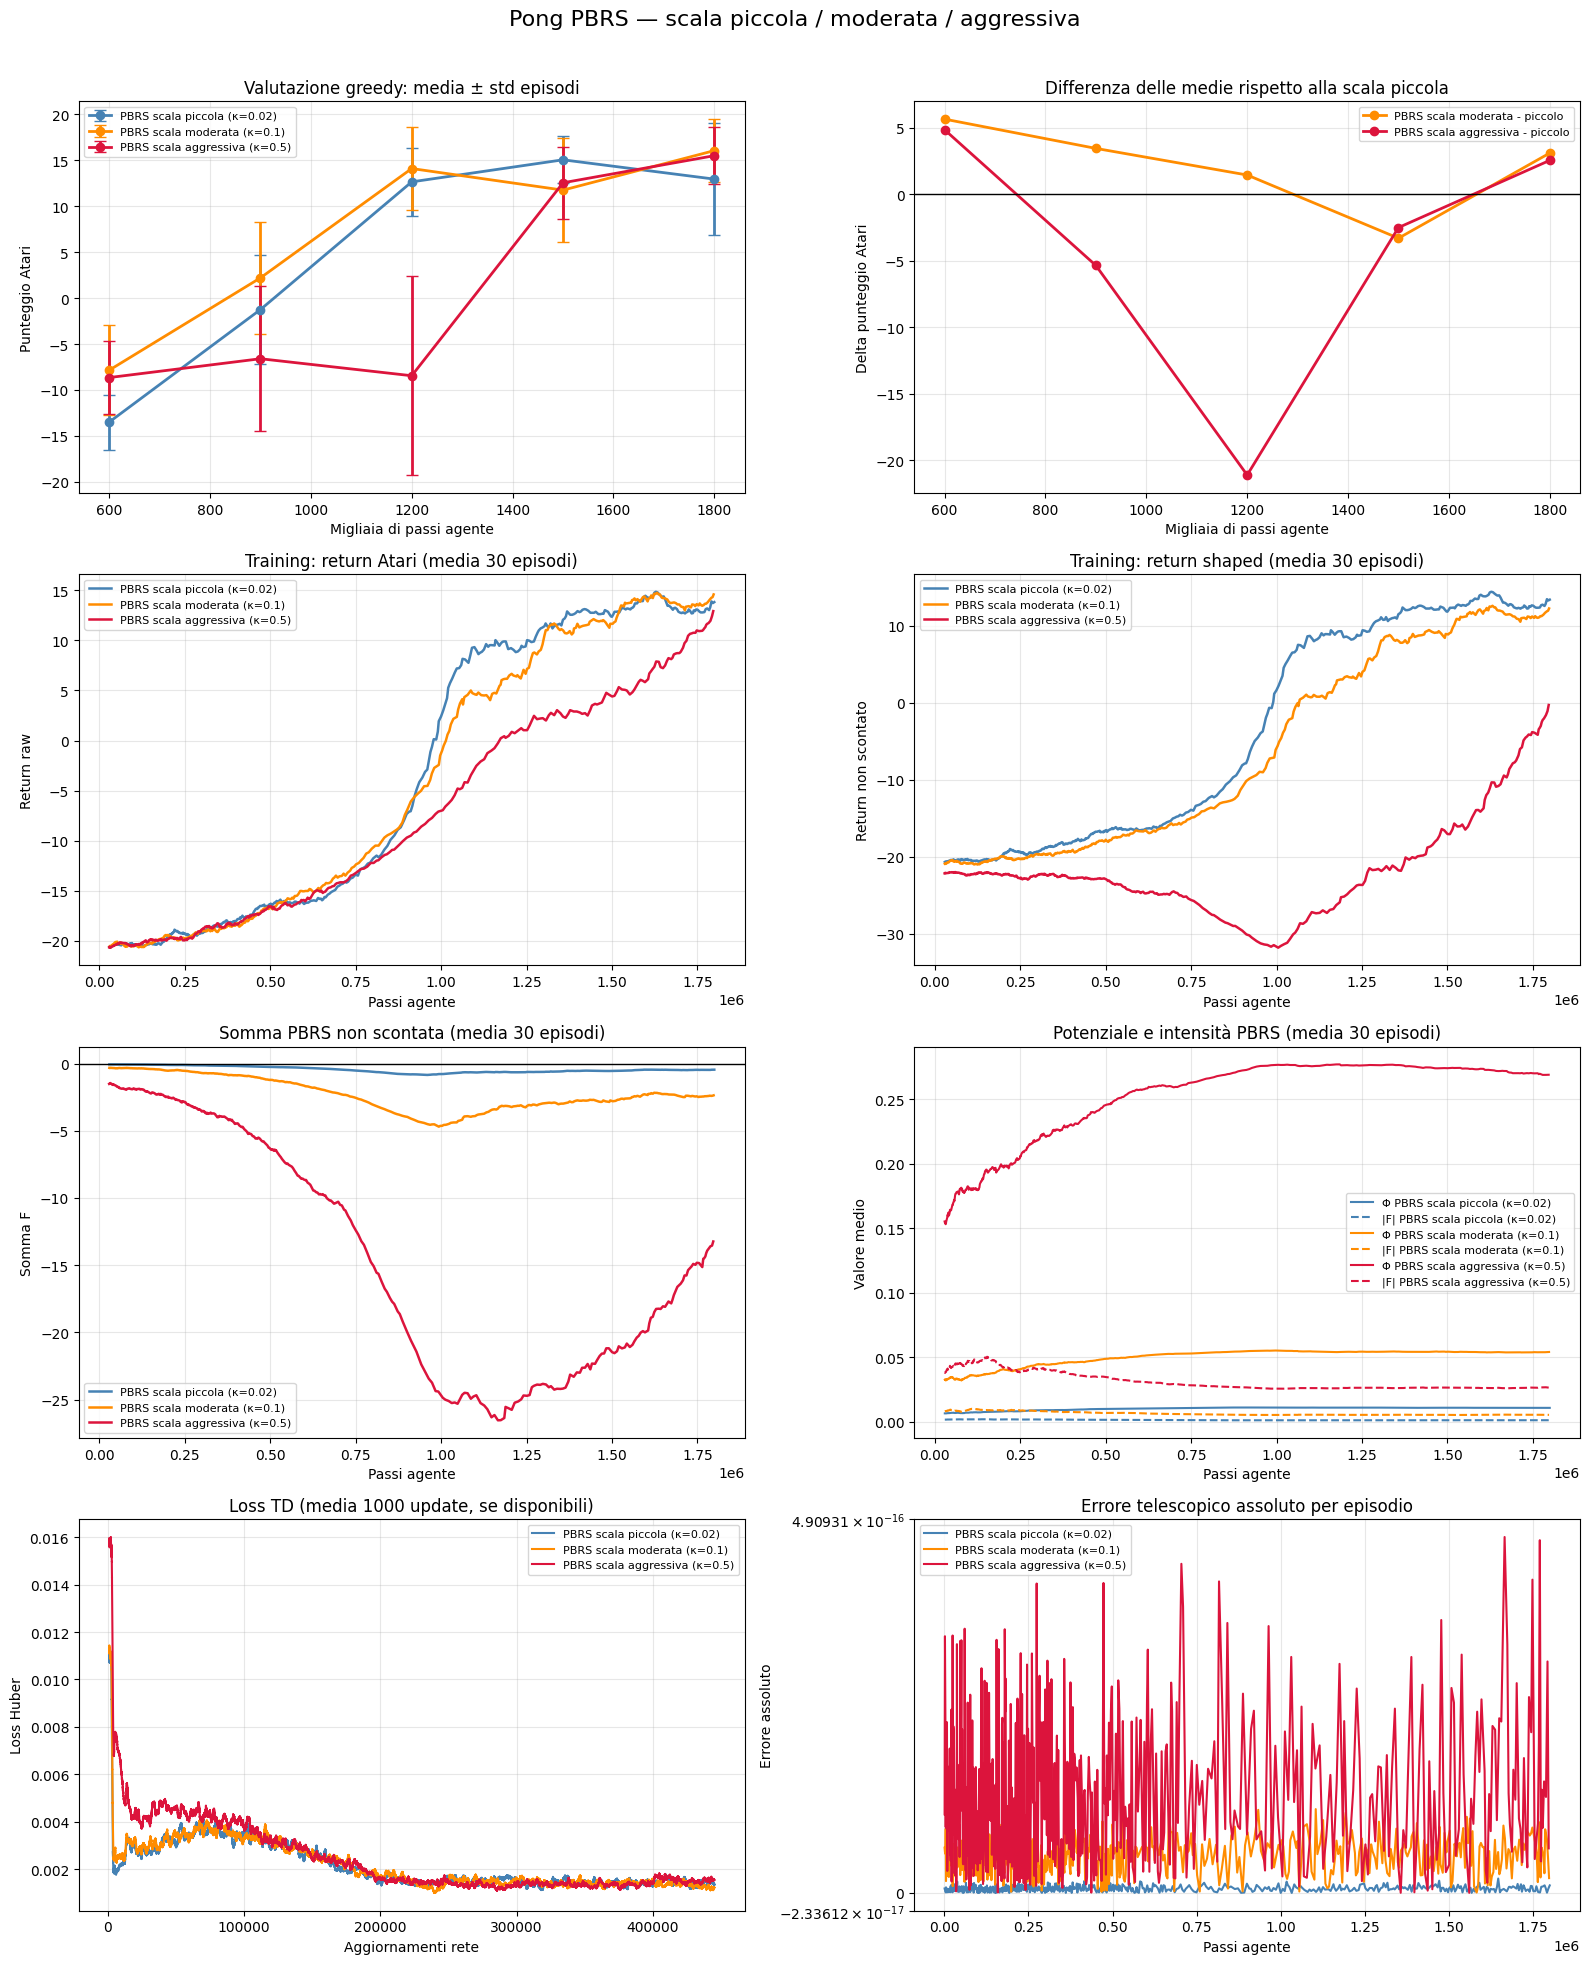

In [11]:
COLORS = {"small": "steelblue", "moderate": "darkorange", "aggressive": "crimson"}
RUNS = [("small", small_run), ("moderate", moderate_run), ("aggressive", aggressive_run)]

def rolling_xy(run, key, window=30):
    values = np.asarray(run["history"][key], dtype=float)
    steps = np.asarray(run["history"]["step"], dtype=float)
    if len(values) < window:
        return np.array([]), np.array([])
    return steps[window-1:], np.convolve(values, np.ones(window)/window, mode="valid")

checkpoint_k = np.asarray(CHECKPOINTS) / 1000.0
small_scores = np.asarray([small_run["checkpoints"][s][0] for s in CHECKPOINTS])
fig, axes = plt.subplots(4, 2, figsize=(16, 20))
ax_eval, ax_delta, ax_raw, ax_shaped, ax_shaping, ax_potential, ax_loss, ax_error = axes.ravel()
for key, run in RUNS:
    color = COLORS[key]
    label = f"{run['label']} (κ={run['potential_scale']:g})"
    scores = np.asarray([run["checkpoints"][s][0] for s in CHECKPOINTS])
    std = np.asarray([run["checkpoints"][s][1] for s in CHECKPOINTS])
    ax_eval.errorbar(checkpoint_k, scores, yerr=std, marker="o", capsize=4,
                     linewidth=2, color=color, label=label)
    if key != "small":
        ax_delta.plot(checkpoint_k, scores-small_scores, marker="o", linewidth=2,
                      color=color, label=run["label"] + " - piccolo")
    for ax, metric in ((ax_raw, "raw_return"), (ax_shaped, "shaped_return"),
                       (ax_shaping, "shaping_sum")):
        x, y = rolling_xy(run, metric)
        ax.plot(x, y, color=color, linewidth=1.8, label=label)
    for metric, style, prefix in (("mean_potential", "-", "Φ"), ("mean_abs_shaping", "--", "|F|")):
        x, y = rolling_xy(run, metric)
        ax_potential.plot(x, y, color=color, linestyle=style, label=prefix + " " + label)
    losses = np.asarray(run["history"]["loss"], dtype=float)
    if len(losses) >= 1000:
        smoothed = np.convolve(losses, np.ones(1000)/1000, mode="valid")
        ax_loss.plot(np.arange(1000, len(losses)+1), smoothed, color=color, label=label)
    else:
        ax_loss.plot(np.arange(1, len(losses)+1), losses, color=color, label=label)
    ax_error.plot(run["history"]["step"], np.abs(run["history"]["telescoping_error"]),
                  color=color, label=label)

ax_eval.set(title="Valutazione greedy: media ± std episodi", xlabel="Migliaia di passi agente", ylabel="Punteggio Atari")
ax_delta.axhline(0, color="black", linewidth=1)
ax_delta.set(title="Differenza delle medie rispetto alla scala piccola", xlabel="Migliaia di passi agente", ylabel="Delta punteggio Atari")
ax_raw.set(title="Training: return Atari (media 30 episodi)", ylabel="Return raw")
ax_shaped.set(title="Training: return shaped (media 30 episodi)", ylabel="Return non scontato")
ax_shaping.axhline(0, color="black", linewidth=1)
ax_shaping.set(title="Somma PBRS non scontata (media 30 episodi)", ylabel="Somma F")
ax_potential.set(title="Potenziale e intensità PBRS (media 30 episodi)", ylabel="Valore medio")
ax_loss.set(title="Loss TD (media 1000 update, se disponibili)", xlabel="Aggiornamenti rete", ylabel="Loss Huber")
ax_error.set(title="Errore telescopico assoluto per episodio", ylabel="Errore assoluto")
ax_error.set_yscale("symlog", linthresh=1e-15)
for ax in (ax_raw, ax_shaped, ax_shaping, ax_potential, ax_error):
    ax.set_xlabel("Passi agente")
for ax in axes.ravel():
    ax.legend(loc="best", fontsize=8)
    ax.grid(True, alpha=0.3)
fig.suptitle("Pong PBRS — scala piccola / moderata / aggressiva", fontsize=16)
plt.tight_layout(rect=(0, 0, 1, 0.97))
plt.savefig("confronto_pbrs_tre_scale.png", dpi=160, bbox_inches="tight")
plt.show()